# Default run

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from contrailstereo import validation as V, vis
from contrailstereo.config import DEFAULT, load_paths
from contrailstereo.data.caliop import load_cases
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.retrieve import load_frames, retrieve

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 180)

CFG     = DEFAULT
SPLIT   = "dev"       # "dev" | "holdout" | "all"
N       = None        # None = every case in the split; an int = a random, fixed subset
MAX_VZA = None
QC      = ("ok",)
N_BOOT  = 2000
FIG_DIR = None        # e.g. load_paths().outputs / "figures" / SPLIT

# pre-registered operating points: (name, r gate, s_eff gate)
OPS = [("reference (r only)",       0.6, 0.0),
       ("confident",                0.65, 1.0),
       ("primary",                  0.7, 1.0)]
PRIMARY = dict(zip(["name", "r", "s"], OPS[2]))

paths = load_paths()
save = lambda name: (FIG_DIR / name) if FIG_DIR else None
if FIG_DIR:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"config {CFG.config_hash()}, split {SPLIT}, outputs {paths.outputs}")

config b18c3fd2ba, split dev, outputs /Users/lewisclark/Documents/python_work/stereo/outputs


## Run

In [ ]:
cases = V.select(load_cases(paths.collocations), SPLIT, n=N, max_vza=MAX_VZA,
                 sats=(CFG.sat_east, CFG.sat_west))
run = V.run(cases, [V.Variant("base", CFG)], paths.outputs / "runs", paths=paths)["base"]
ids = {c.id for c in cases}
run = V.Run(run.variant, run.cases[run.cases.case_id.isin(ids)], run.profiles)
by_id = {c.id: c for c in cases}
if run.profiles.s_eff.isna().all():
    raise RuntimeError("this run has no s_eff: it was made before s_eff was stored")
print(f"{len(run.cases)} cases ({SPLIT}), {len(run.profiles)} truth points, "
      f"{run.profiles.groupby(['case_id', 'contrail']).ngroups} contrails")
run.cases.qc.value_counts().to_frame("cases")

359 cases x 1 variants; 4 cases need work


[INFO] - G17 C13 domain C unavailable: noaa-goes17/ABI-L2-CMIPC/2022/014/22
[INFO] - G17 C13 domain F unavailable: noaa-goes17/ABI-L2-CMIPF/2022/014/22
Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 238, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 234, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [1/4]         base scene   79 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


[INFO] - G16 C13 domain C unavailable: noaa-goes16/ABI-L2-CMIPC/2022/256/11
[INFO] - G16 C13 domain F unavailable: noaa-goes16/ABI-L2-CMIPF/2022/256/11
Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 238, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 234, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11


  [2/4]         base scene  495 qc=error    FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11


[INFO] - G17 C13 domain C unavailable: noaa-goes17/ABI-L2-CMIPC/2022/014/22
[INFO] - G17 C13 domain F unavailable: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [3/4]         base scene  379 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
  [4/4]         base scene  460 qc=error    ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}
359 cases (dev), 23112 truth points, 953 contrails


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 238, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 234, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 238, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 234, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}


,cases
qc,
ok,230
coverage,84
no_data,33
offset,8
error,4


## Per point

Per truth point, at each operating point. `yield` is the share of usable cases; `coverage` is the share of truth points **in usable cases** that pass both gates. `rmse_corr` removes a leave-one-case-out bias constant. `within` and `between` split it into matching precision inside a case and the spread of case offsets. Intervals come from resampling cases.

In [ ]:
rows = []
for name, rg, sm in OPS:
    s = V.summary(run, rg, QC, n_boot=N_BOOT, s_min=sm)
    ci = lambda k: f"{s[k]:.3f} [{s[k + '_ci'][0]:.3f}, {s[k + '_ci'][1]:.3f}]"
    rows.append({"operating point": name, "r >": rg, "s_eff ≥": sm, "points": int(s["n"]),
                 "cases": s["n_cases_scored"], "yield": f"{s['yield']:.2f}",
                 "coverage": f"{s['coverage']:.2f}", "bias": ci("bias"),
                 "rmse_raw": f"{s['rmse_raw']:.3f}", "rmse_corr": ci("rmse_corr"),
                 "within": f"{s['within']:.3f}", "between": ci("between")})
pd.DataFrame(rows).set_index("operating point")

/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:404: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ok = _passes(p, gate, s_min) & p.case_id.map(use).fillna(
/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:494: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  q = p[p.case_id.map(use).fillna(False).astype(bool) & _passes(p, gate, s_min)]
/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:404: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is

,r >,s_eff ≥,points,cases,yield,coverage,bias,rmse_raw,rmse_corr,within,between
operating point,,,,,,,,,,,
reference (r only),0.600,0.000,8571,191,0.65,0.75,"-0.263 [-0.317, -0.208]",0.607,"0.550 [0.468, 0.651]",0.397,"0.381 [0.320, 0.449]"
confident,0.650,1.000,6738,152,0.65,0.59,"-0.248 [-0.304, -0.189]",0.503,"0.439 [0.397, 0.484]",0.316,"0.304 [0.269, 0.343]"
primary,0.700,1.000,6257,141,0.65,0.55,"-0.245 [-0.303, -0.183]",0.499,"0.437 [0.393, 0.484]",0.309,"0.308 [0.273, 0.348]"


## Per contrail (comparable with Meijer et al. 2024)

A contrail is a contiguous run of CALIOP points (split at gaps > 5 km), assigned when the run is made. Its height is the median of its points passing the gates, and it's scored if at least 3 pass. Coverage is within the stereo domain (usable cases).

In [ ]:
MIN_PTS = 3
rows = []
for name, rg, sm in OPS:
    c = V.contrail_summary(run, rg, QC, min_points=MIN_PTS, n_boot=N_BOOT, s_min=sm)
    ci = lambda k: f"{c[k]:.3f} [{c[k + '_ci'][0]:.3f}, {c[k + '_ci'][1]:.3f}]"
    rows.append({"operating point": name, "r >": rg, "s_eff ≥": sm,
                 "contrails": f"{c['n_scored']}/{c['n_contrails']}",
                 "coverage": f"{c['contrail_coverage']:.2f}", "bias": ci("bias"),
                 "RMSE raw": ci("rmse_raw"), "RMSE corr": ci("rmse_corr")})
rows += [{"operating point": "Meijer et al. 2024 CNN", "coverage": "all", "RMSE raw": "0.570"},
         {"operating point": "Google CNN (attribution-trained)", "coverage": "all",
          "RMSE raw": "0.789"}]
pd.DataFrame(rows).set_index("operating point").fillna("")

,r >,s_eff ≥,contrails,coverage,bias,RMSE raw,RMSE corr
operating point,,,,,,,
reference (r only),0.600,0.000,337/451,0.75,"-0.255 [-0.320, -0.191]","0.633 [0.507, 0.761]","0.581 [0.452, 0.712]"
confident,0.600,1.000,276/451,0.61,"-0.249 [-0.303, -0.195]","0.493 [0.433, 0.554]","0.428 [0.365, 0.492]"
primary,0.700,1.000,241/451,0.53,"-0.253 [-0.306, -0.201]","0.463 [0.403, 0.530]","0.390 [0.337, 0.452]"
Meijer et al. 2024 CNN,,,,all,,0.570,
Google CNN (attribution-trained),,,,all,,0.789,


## Sensitivity to the two gates, per contrail

Every combination of r and `s_eff` gates: the effect of each with the other held fixed, and the best combination at each coverage (the frontier) against the r-only curve. The printout compares them at matched coverage (±0.05). **Selection happens on dev only**; on holdout this is a description, not a menu.

coverage ~0.5: r only 0.499 (r>0.80, cov 0.49) | best 0.370 (r>0.65, s_eff≥1.25, cov 0.45) | gain +0.129 km
coverage ~0.6: r only 0.519 (r>0.75, cov 0.59) | best 0.397 (r>0.65, s_eff≥1.00, cov 0.58) | gain +0.122 km
coverage ~0.7: r only 0.500 (r>0.70, cov 0.65) | best 0.485 (r>0.65, s_eff≥0.75, cov 0.66) | gain +0.015 km


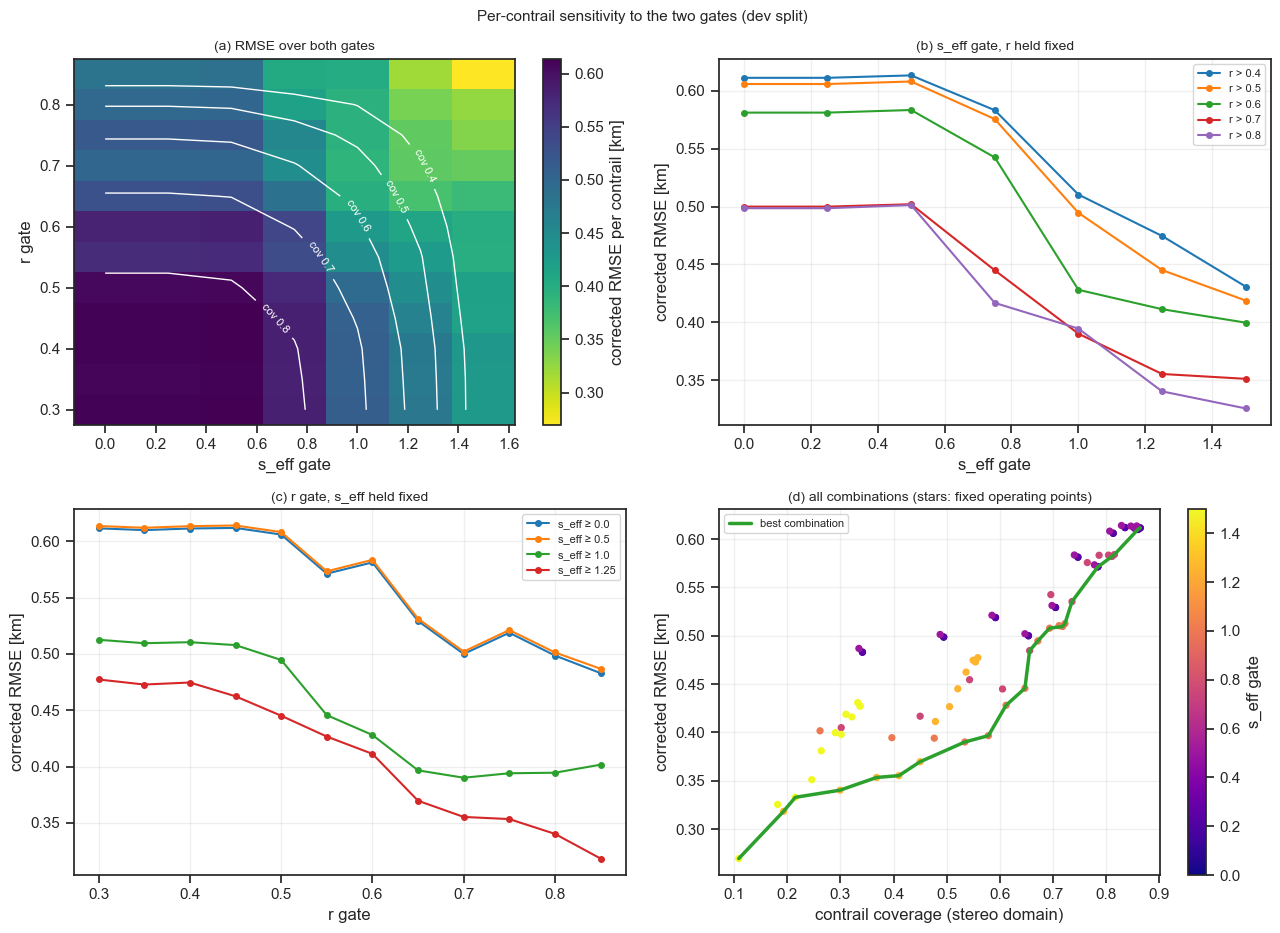

In [ ]:
R_GRID = np.round(np.arange(0.30, 0.86, 0.05), 2)
S_GRID = np.round(np.arange(0.0, 1.51, 0.25), 2)
sw = pd.DataFrame([dict(r=rg, s_min=sm, **{k: v for k, v in V.contrail_summary(
    run, rg, QC, min_points=MIN_PTS, n_boot=0, s_min=sm).items()
    if k in ("contrail_coverage", "n_scored", "bias", "rmse_raw", "rmse_corr")})
    for sm in S_GRID for rg in R_GRID]).rename(columns={"contrail_coverage": "coverage"})
piv = lambda col: sw.pivot(index="r", columns="s_min", values=col)

fig, axs = plt.subplots(2, 2, figsize=(13, 9.5))
ax = axs[0, 0]
im = ax.pcolormesh(S_GRID, R_GRID, piv("rmse_corr").values, shading="nearest", cmap="viridis_r")
fig.colorbar(im, ax=ax, label="corrected RMSE per contrail [km]")
cs = ax.contour(S_GRID, R_GRID, piv("coverage").values, levels=(0.4, 0.5, 0.6, 0.7, 0.8),
                colors="w", linewidths=1)
ax.clabel(cs, fmt=lambda v: f"cov {v:.1f}", fontsize=8)
ax.set_xlabel("s_eff gate"); ax.set_ylabel("r gate"); ax.set_title("(a) RMSE over both gates", fontsize=10)
ax = axs[0, 1]
for rg in (0.4, 0.5, 0.6, 0.7, 0.8):
    g_ = sw[sw.r == rg]; ax.plot(g_.s_min, g_.rmse_corr, "o-", ms=4, label=f"r > {rg}")
ax.set_xlabel("s_eff gate"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(b) s_eff gate, r held fixed", fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axs[1, 0]
for sm in (0.0, 0.5, 1.0, 1.25):
    g_ = sw[sw.s_min == sm]; ax.plot(g_.r, g_.rmse_corr, "o-", ms=4, label=f"s_eff ≥ {sm}")
ax.set_xlabel("r gate"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(c) r gate, s_eff held fixed", fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axs[1, 1]
sc = ax.scatter(sw.coverage, sw.rmse_corr, c=sw.s_min, cmap="plasma", s=18)
fig.colorbar(sc, ax=ax, label="s_eff gate")
r0 = sw[sw.s_min == 0].sort_values("coverage")
#ax.plot(r0.coverage, r0.rmse_corr, "k--", lw=1.5, label="r gate only")
pts_ = sw.dropna(subset=["rmse_corr"]).sort_values("coverage", ascending=False)
front = pts_[pts_.rmse_corr == pts_.rmse_corr.cummin()]
ax.plot(front.coverage, front.rmse_corr, "-", color="C2", lw=2.5, label="best combination")
#for name, rg, sm in OPS:
#    o = sw[(sw.r == rg) & (sw.s_min == sm)]
#    ax.plot(o.coverage, o.rmse_corr, "*", ms=14, mec="k", mfc="w", zorder=5)
#    ax.annotate(name, (o.coverage.iloc[0], o.rmse_corr.iloc[0]), fontsize=7,
#                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("contrail coverage (stereo domain)"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(d) all combinations (stars: fixed operating points)", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f"Per-contrail sensitivity to the two gates ({SPLIT} split)", fontsize=11)
fig.tight_layout()
if FIG_DIR:
    fig.savefig(save("gate_sensitivity.pdf"), bbox_inches="tight")

def near(d, target, tol=0.05):
    d = d.dropna(subset=["rmse_corr"]); d = d[(d.coverage - target).abs() <= tol]
    return None if d.empty else d.loc[d.rmse_corr.idxmin()]
for target in (0.5, 0.6, 0.7):
    a, b = near(sw[sw.s_min == 0], target), near(sw, target)
    print(f"coverage ~{target:.1f}: " + ("no grid point within ±0.05" if a is None or b is None else
          f"r only {a.rmse_corr:.3f} (r>{a.r:.2f}, cov {a.coverage:.2f}) | best {b.rmse_corr:.3f} "
          f"(r>{b.r:.2f}, s_eff≥{b.s_min:.2f}, cov {b.coverage:.2f}) | gain {a.rmse_corr - b.rmse_corr:+.3f} km"))

## Figures at the primary operating point

/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:404: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ok = _passes(p, gate, s_min) & p.case_id.map(use).fillna(
/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:494: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  q = p[p.case_id.map(use).fillna(False).astype(bool) & _passes(p, gate, s_min)]
/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/vis.py:156: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprec

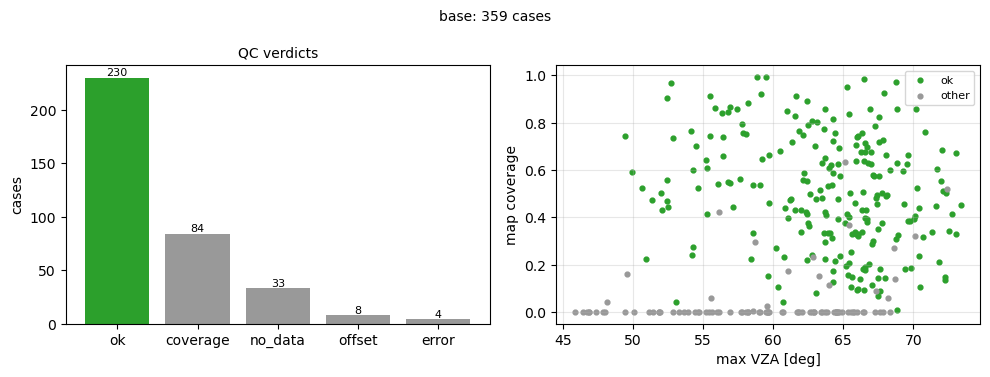

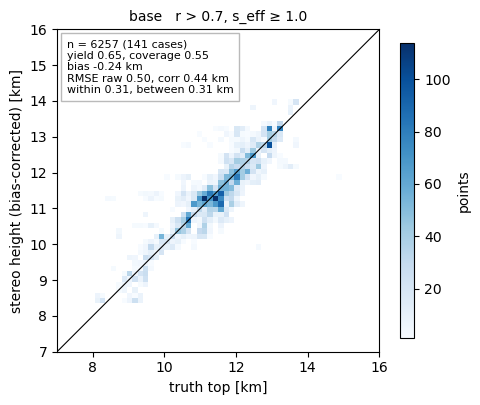

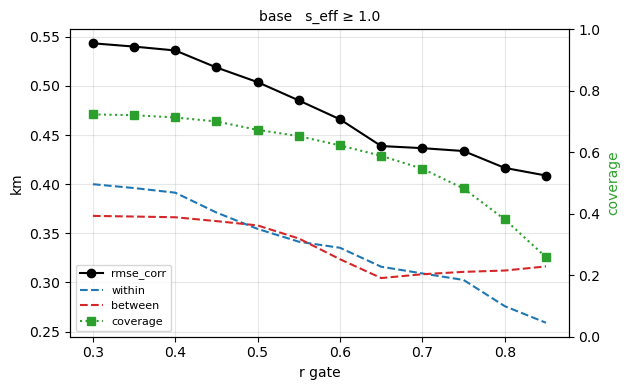

In [ ]:
vis.run_overview(run, save=save("overview.pdf"))
vis.truth_scatter(run, PRIMARY["r"], QC, s_min=PRIMARY["s"], save=save("truth_scatter.pdf"))
vis.gate_tradeoff(run, qc=QC, s_min=PRIMARY["s"], save=save("gate_tradeoff.pdf"));

## Where the error comes from

Cases ranked by their share of the squared corrected error at the primary operating point, with their median `s_eff`. A few cases dominating means the headline RMSE is fragile, so read it together with the robust numbers below.

In [ ]:
ct = V.case_table(run, PRIMARY["r"], QC, s_min=PRIMARY["s"])
med_s = run.profiles.groupby("case_id").s_eff.median()
ct["s_eff_median"] = ct.case_id.map(med_s)
ctab = V.contrail_table(run, PRIMARY["r"], QC, min_points=MIN_PTS, s_min=PRIMARY["s"])
e = ctab[ctab.scored].err - ctab[ctab.scored].err.mean()
print(f"top 5 cases carry {ct.sse_share.head(5).sum():.0%} of squared error; "
      f"{(ct.offset.abs() > 1).sum()} cases with |offset| > 1 km")
print(f"per contrail, bias-removed: median |error| {e.abs().median():.3f} km, "
      f"within 0.5 km {(e.abs() <= 0.5).mean():.0%}, within 1 km {(e.abs() <= 1).mean():.0%}")
ct.head(15)

/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py:404: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ok = _passes(p, gate, s_min) & p.case_id.map(use).fillna(


NameError: name 'MIN_PTS' is not defined

## Inspect a case

In [ ]:
SCENE = None
row = ct.iloc[0] if SCENE is None else run.cases[run.cases.scene == SCENE].iloc[0]
case = by_id[row.case_id]

cfg_nb = CFG.set(stripe_mask=False)
frames = load_frames(case, cfg_nb, paths)          
res = retrieve(case, cfg_nb, paths, frames=frames)

#frames = load_frames(case, CFG, paths)
#res = retrieve(case, CFG, paths, frames=frames)
truth = V.attach_truth(res, case)
h_ref = res.diag.get("s_eff_h_ref", 11.0)
E = frames[(CFG.sat_east, 0)]
alat, alon = apparent_surface_latlon(res.grid.lat, res.grid.lon, h_ref * 1e3, E.sat_lon)
vis.map_panel(res, truth, btd=E.view(alat, alon), save=save(f"scene_{case.meta['scene']}.pdf"), h_lims=[8.0,12.0])
plt.show()

## Case 41

Re-runs the retrieval for one scene from the GOES cache and shows the reference-view BTD (parallax-corrected to the scene's median height), height, peak r and `s_eff`. Default: the case with the largest error share at the primary point.

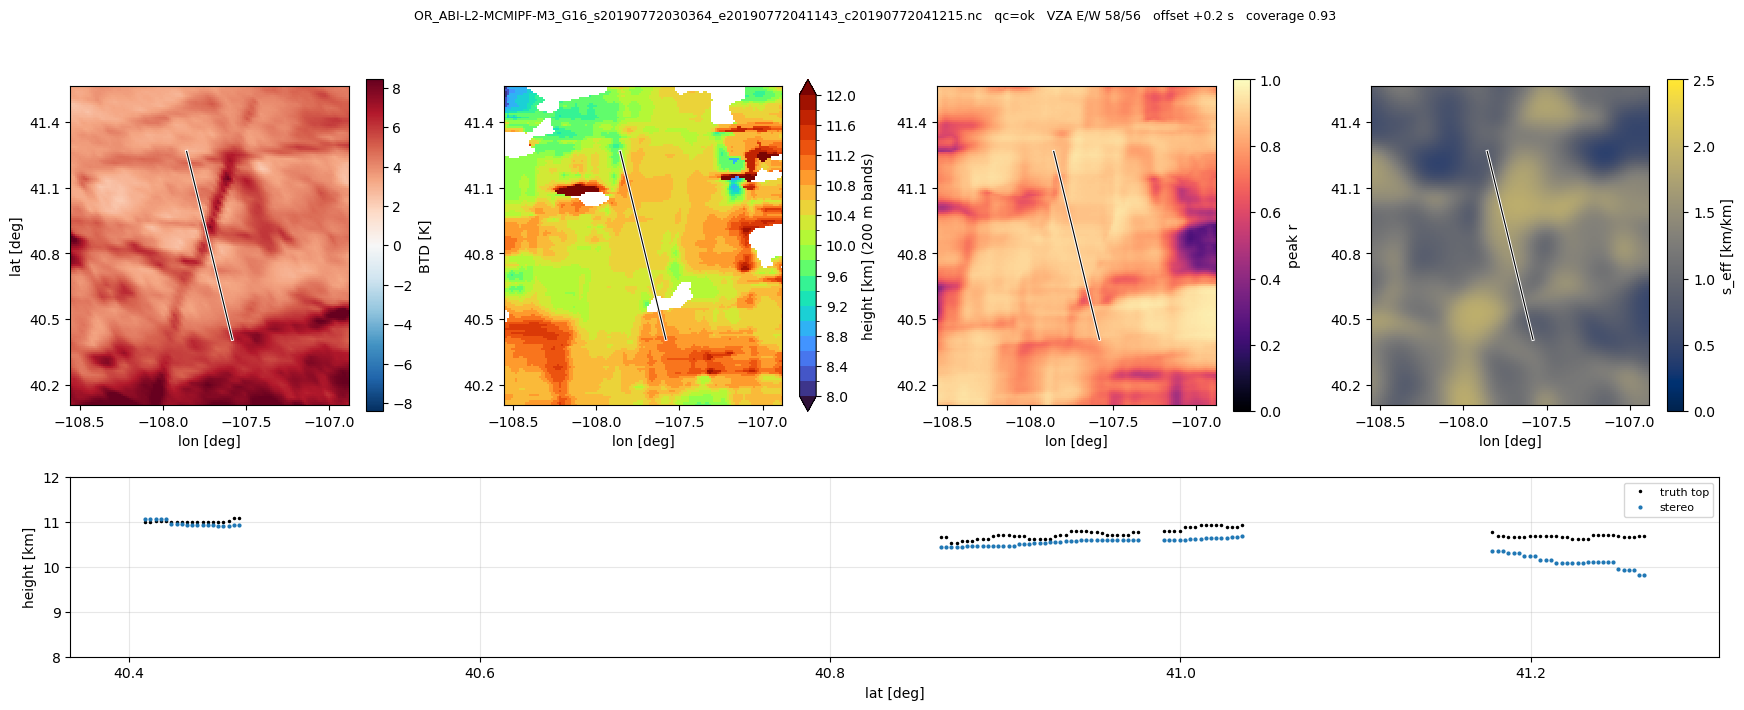

In [ ]:
SCENE = 41
row = ct.iloc[0] if SCENE is None else run.cases[run.cases.scene == SCENE].iloc[0]
case = by_id[row.case_id]

cfg_nb = CFG.set(stripe_mask=False)
frames = load_frames(case, cfg_nb, paths)          
res = retrieve(case, cfg_nb, paths, frames=frames)

#frames = load_frames(case, CFG, paths)
#res = retrieve(case, CFG, paths, frames=frames)
truth = V.attach_truth(res, case)
h_ref = res.diag.get("s_eff_h_ref", 11.0)
E = frames[(CFG.sat_east, 0)]
alat, alon = apparent_surface_latlon(res.grid.lat, res.grid.lon, h_ref * 1e3, E.sat_lon)
vis.map_panel(res, truth, btd=E.view(alat, alon), save=save(f"scene_{case.meta['scene']}.pdf"), h_lims=[8.0,12.0])
plt.show()

Text(0.5, 1.0, 'scene 41: CALIOP L1 backscatter')

/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


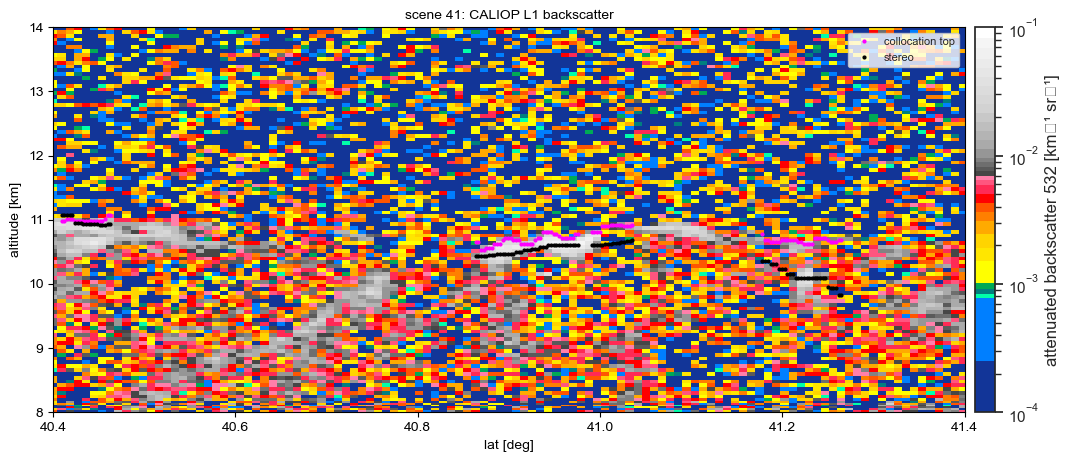

In [ ]:
# ---- CALIOP Level 1 backscatter curtain for this case ------------------------------
import json
import earthaccess
from pyhdf.SD import SD, SDC
from matplotlib.colors import LogNorm
L1_SHORT = "CAL_LID_L1-Standard-V4-51"
L1_DIR = paths.goes_cache.parent / "caliop_l2" / "l1"; L1_DIR.mkdir(parents=True, exist_ok=True)
L1_INDEX = L1_DIR / "index.json"
SMOOTH = 3                     # profiles averaged together (~1 km)
Z_LIMS = (8.0, 14.0)           # altitude range to plot [km]

auth = earthaccess.login(persist=True)

def _utc(t):
    d = np.floor(t); yy = np.floor(d / 10000)
    mm = np.floor((d - yy * 10000) / 100); dd = d - yy * 10000 - mm * 100
    base = pd.to_datetime(dict(year=(2000 + yy).astype(int), month=mm.astype(int), day=dd.astype(int)))
    return (base + pd.to_timedelta(t - d, unit="D")).values

def lidar_altitudes(path=None):
    if path:
        try:
            from pyhdf.HDF import HDF, HC
            import pyhdf.VS                                    # noqa: F401  (registers vstart)
            h = HDF(str(path), HC.READ); vs = h.vstart()
            vd = vs.attach(vs.find("metadata")); rec = vd.read(1)[0]
            a = np.asarray(rec[vd._fields.index("Lidar_Data_Altitudes")], float)
            vd.detach(); vs.end(); h.close()
            if a.size == 583:
                return a
        except Exception as e:                                 # noqa: BLE001
            print(f"  (altitude metadata unreadable: {e}; using the standard grid)")
    spec = [(40.0, 30.1, 0.300), (30.1, 20.2, 0.180), (20.2, 8.2, 0.060),
            (8.2, -0.5, 0.030), (-0.5, -2.0, 0.300)]
    return np.concatenate([hi - dz * (np.arange(int(round((hi - lo) / dz))) + 0.5)
                           for hi, lo, dz in spec])

def l1_granules(case, pad_min=3, pad_deg=1.0):
    idx = json.loads(L1_INDEX.read_text()) if L1_INDEX.exists() else {}
    if case.id in idx and all((L1_DIR / f).exists() for f in idx[case.id]):
        return [L1_DIR / f for f in idx[case.id]]
    t = case.truth
    t0 = (t.time.min() - pd.Timedelta(minutes=pad_min)).strftime("%Y-%m-%dT%H:%M:%S")
    t1 = (t.time.max() + pd.Timedelta(minutes=pad_min)).strftime("%Y-%m-%dT%H:%M:%S")
    bbox = (float(t.lon.min() - pad_deg), float(t.lat.min() - pad_deg),
            float(t.lon.max() + pad_deg), float(t.lat.max() + pad_deg))
    r = earthaccess.search_data(short_name=L1_SHORT, temporal=(t0, t1), bounding_box=bbox)
    if not r:
        raise LookupError(f"no {L1_SHORT} granule for {t0}..{t1} {bbox}")
    files = [str(p) for p in earthaccess.download(r, str(L1_DIR))]
    idx = json.loads(L1_INDEX.read_text()) if L1_INDEX.exists() else {}
    idx[case.id] = sorted({p.split("/")[-1] for p in files}); L1_INDEX.write_text(json.dumps(idx, indent=1))
    return [L1_DIR / f for f in idx[case.id]]

def read_l1(paths_, case, pad_s=20.0):
    t0 = case.truth.time.min() - pd.Timedelta(seconds=pad_s)
    t1 = case.truth.time.max() + pd.Timedelta(seconds=pad_s)
    parts = []
    for p in paths_:
        f = SD(str(p), SDC.READ)
        tt = _utc(f.select("Profile_UTC_Time")[:, 0])
        m = (tt >= np.datetime64(t0)) & (tt <= np.datetime64(t1))
        if m.any():
            i0, i1 = (int(v) for v in np.where(m)[0][[0, -1]])
            parts.append(dict(lat=f.select("Latitude")[i0:i1 + 1, 0].astype(float),
                              beta=f.select("Total_Attenuated_Backscatter_532")[i0:i1 + 1, :].astype(float),
                              alt=lidar_altitudes(p)))
        f.end()
    if not parts:
        raise LookupError("no L1 profiles in the case's time window")
    s = {k: np.concatenate([q[k] for q in parts]) for k in ("lat", "beta")}
    s["alt"] = parts[0]["alt"]
    n = (s["lat"].size // SMOOTH) * SMOOTH
    s["lat"] = s["lat"][:n].reshape(-1, SMOOTH).mean(1)
    s["beta"] = s["beta"][:n].reshape(-1, SMOOTH, s["beta"].shape[1]).mean(1)
    return s

s = read_l1(l1_granules(case), case)
kz = (s["alt"] >= Z_LIMS[0]) & (s["alt"] <= Z_LIMS[1])
fig, ax = plt.subplots(figsize=(14, 5))
import warnings; warnings.filterwarnings("ignore", message=".*earthcarekit.*")
import earthcarekit as eck
CMAP = eck.get_cmap("calipso")        # or "calipso_smooth", "chiljet2"
BETA_LIMS = (1e-4, 1e-1)              # km-1 sr-1: the usual CALIPSO browse range

pm = ax.pcolormesh(s["lat"], s["alt"][kz], np.clip(s["beta"][:, kz], BETA_LIMS[0], None).T,
                   norm=LogNorm(vmin=BETA_LIMS[0], vmax=BETA_LIMS[1]), cmap=CMAP,
                   shading="nearest", rasterized=True)
fig.colorbar(pm, ax=ax, pad=0.01, label="attenuated backscatter 532 [km⁻¹ sr⁻¹]")
ts = truth.sort_values("lat")
ax.plot(ts.lat, ts.top_km, ".", ms=4, color="magenta", label="collocation top")
ax.plot(ts.lat, ts.h, ".", ms=4, color="k", label="stereo")
ax.set_xlabel("lat [deg]"); ax.set_ylabel("altitude [km]"); ax.set_ylim(*Z_LIMS)
ax.set_xlim(40.4,41.4)
ax.legend(fontsize=8); ax.set_title(f"scene {case.meta['scene']}: CALIOP L1 backscatter", fontsize=10)

{'stripe_max': 7.077865475127584, 'stripe_rows': 31, 'offset_s': 0.248281, 'vza_east': 57.80173360068726, 'vza_west': 56.06684269764113, 'map_coverage': 0.9346938775510204}


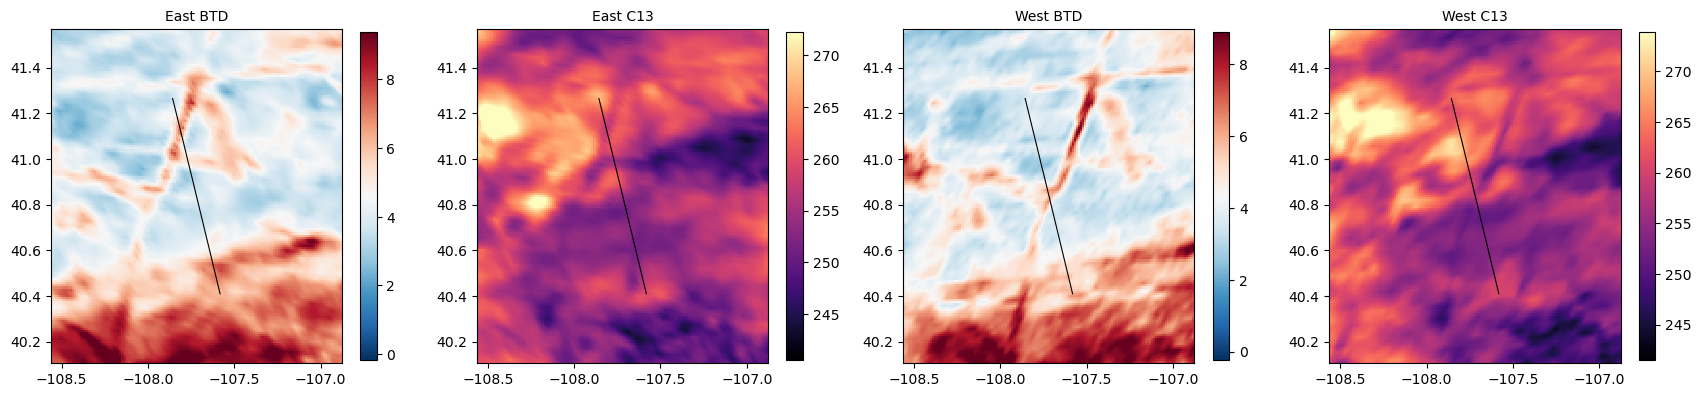

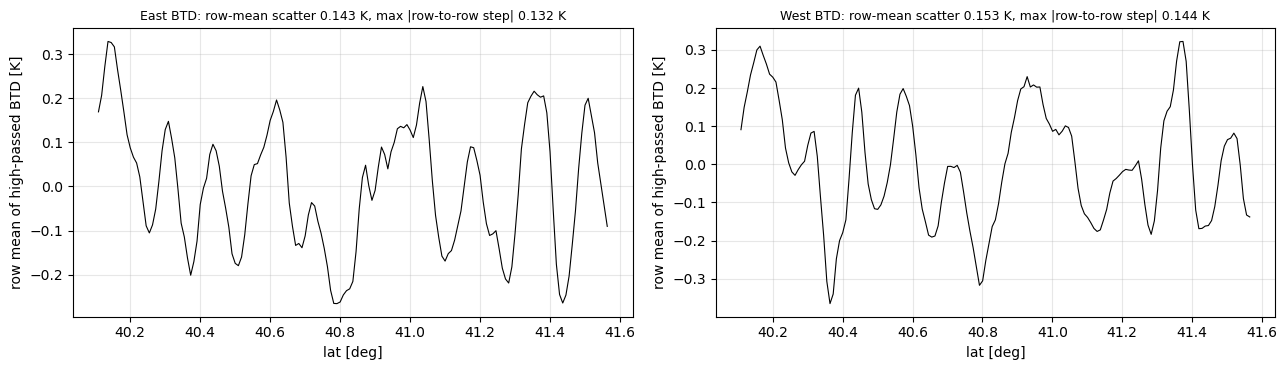

In [ ]:
# ---- East vs West: banding / striping check ---------------------------------------
from contrailstereo.data.goes import fetch_channels
from contrailstereo.prep import btd_view, highpass
from contrailstereo.geometry import km_filters
g = res.grid
sig = km_filters(g, CFG)[0]
d_ = res.diag
print({k: d_.get(k) for k in ("stripe_max", "stripe_rows", "offset_s", "vza_east", "vza_west",
                              "map_coverage")})

def channel_view(sat, ch):
    f, _ = fetch_channels(sat, (ch,), case.time, paths.goes_cache)
    ds = f[ch]; zero = ds.copy(); zero["CMI"] = ds["CMI"] * 0
    return btd_view(ds, zero)

panels = []
for sat, lab in ((CFG.sat_east, "East"), (CFG.sat_west, "West")):
    panels.append((f"{lab} BTD", frames[(sat, 0)].view(g.lat, g.lon)))
    try:
        panels.append((f"{lab} C13", channel_view(sat, 13)(g.lat, g.lon)))
    except Exception as e:                                               # noqa: BLE001
        print(f"{lab} C13 unavailable: {type(e).__name__}: {e}")

fig, axs = plt.subplots(1, len(panels), figsize=(4.3 * len(panels), 4.4))
for ax, (lab, Z) in zip(axs, panels):
    med = np.nanmedian(Z); v = np.nanpercentile(np.abs(Z - med), 99)
    pm = ax.pcolormesh(g.lon, g.lat, Z, cmap="RdBu_r" if "BTD" in lab else "magma",
                       vmin=med - v, vmax=med + v, shading="auto")
    fig.colorbar(pm, ax=ax, shrink=0.8)
    ax.plot(truth.lon, truth.lat, "k-", lw=0.8)
    ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0]))); ax.set_title(lab, fontsize=10)
fig.tight_layout()

# row anomalies: striping shows as a saw-tooth in the row means of the high-passed field
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, (lab, Z) in zip(axs, [p for p in panels if "BTD" in p[0]]):
    rows_ = np.nanmean(highpass(Z, sig), axis=1)
    ax.plot(g.lat1d, rows_, "k-", lw=0.8)
    ax.set_xlabel("lat [deg]"); ax.set_ylabel("row mean of high-passed BTD [K]")
    sd = np.nanstd(rows_)
    ax.set_title(f"{lab}: row-mean scatter {sd:.3f} K, "
                 f"max |row-to-row step| {np.nanmax(np.abs(np.diff(rows_))):.3f} K", fontsize=9)
    ax.grid(alpha=0.3)
fig.tight_layout()

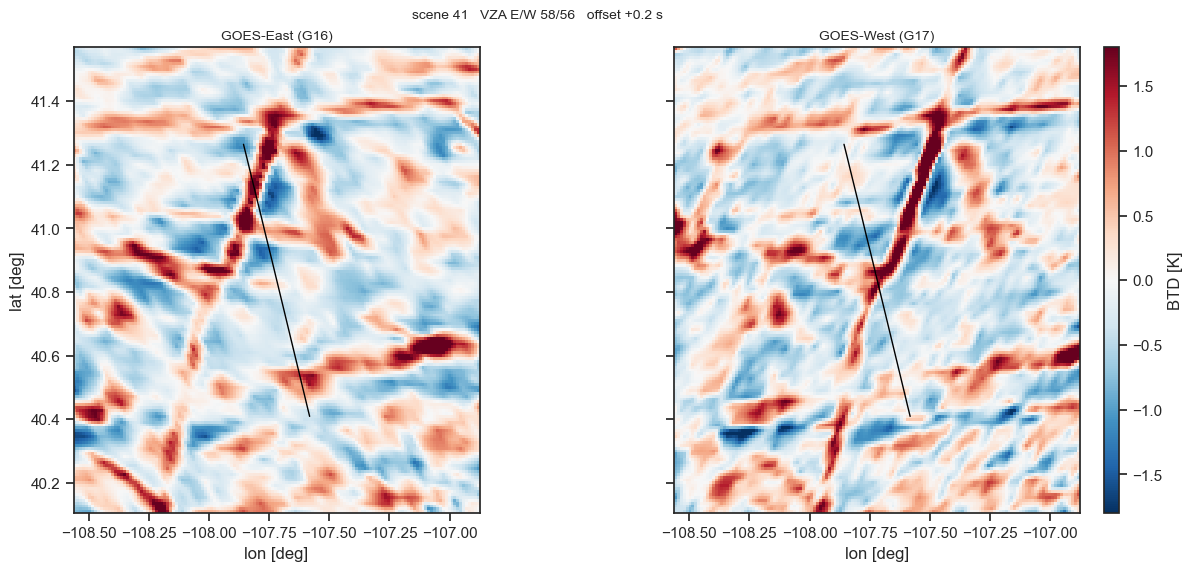

In [ ]:
# ---- The two GOES views, no parallax correction, shared colour bar ------------------
HIGHPASS = True          # True = remove the large-scale background (as the matcher sees it)
g = res.grid
imgs = {}
for sat, lab in ((CFG.sat_east, f"GOES-East (G{CFG.sat_east})"), (CFG.sat_west, f"GOES-West (G{CFG.sat_west})")):
    Z = frames[(sat, 0)].view(g.lat, g.lon)         # raw geolocation: no height correction
    if HIGHPASS:
        from contrailstereo.prep import highpass
        from contrailstereo.geometry import km_filters
        Z = highpass(Z, km_filters(g, CFG)[0])
    imgs[lab] = Z

allZ = np.concatenate([Z[np.isfinite(Z)].ravel() for Z in imgs.values()])
med = 0.0 if HIGHPASS else np.median(allZ)
v = np.percentile(np.abs(allZ - med), 99)           # one scale for both panels

fig, axs = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True,
                        constrained_layout=True)
for ax, (lab, Z) in zip(axs, imgs.items()):
    pm = ax.pcolormesh(g.lon, g.lat, Z, cmap="RdBu_r", vmin=med - v, vmax=med + v, shading="auto")
    if "truth" in globals():
        ax.plot(truth.lon, truth.lat, "k-", lw=1)
    ax.set_xlabel("lon [deg]"); ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0])))
    ax.set_title(f"{lab}", fontsize=10)
axs[0].set_ylabel("lat [deg]")
fig.colorbar(pm, ax=axs, shrink=1.0, aspect=30, pad=0.02, label="BTD [K]")
fig.suptitle(f"scene {case.meta['scene']}   VZA E/W "
             f"{res.diag['vza_east']:.0f}/{res.diag['vza_west']:.0f}   "
             f"offset {res.diag['offset_s']:+.1f} s", fontsize=10)

plt.savefig("/Users/lewisclark/Documents/python_work/stereo/outputs/Figures/scene_41_raw_btd.pdf")

pixel (40.863N, -107.727E) -> grid [83, 69]; window 25x25 px = 25x25 km


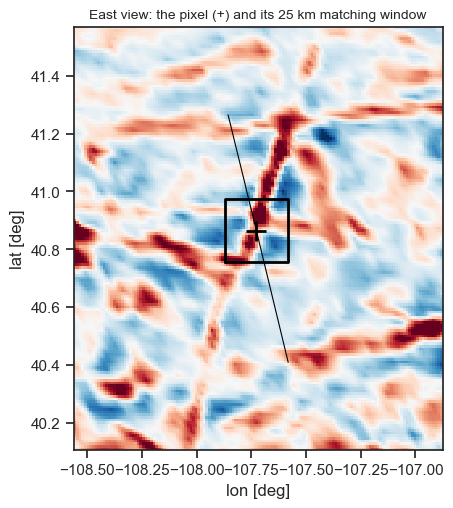

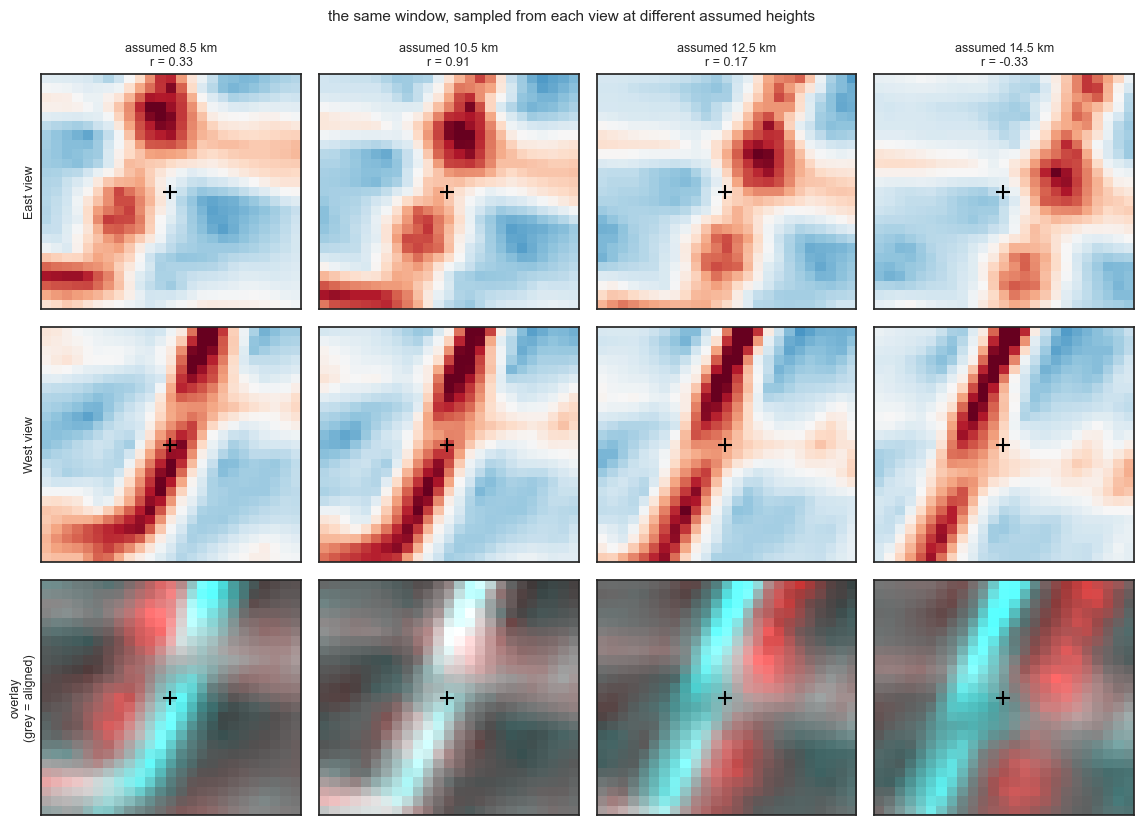

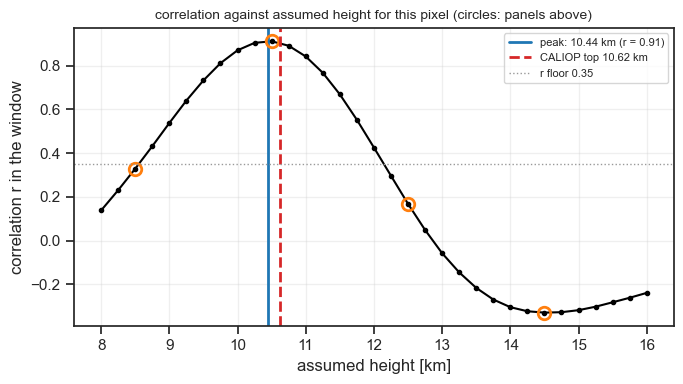

In [ ]:
# ---- How one pixel is matched: window, trial heights, correlation curve ------------
from contrailstereo.prep import make_preps
from contrailstereo.retrieve import project, height_scan, load_winds
from contrailstereo.geometry import km_filters, locate, apparent_surface_latlon
PIX = None            # (lat, lon); None = the truth point with the highest peak r
SHOW_H = None         # heights to display; None = peak and +-2, +-4 km around it

E, W = CFG.sat_east, CFG.sat_west
g = res.grid
preps, _ = make_preps(g, (E, W), CFG)
wind = (load_winds(case, CFG, paths)
        if abs(res.diag["offset_s"]) >= CFG.wind_min_offset_s else None)
_, win = km_filters(g, CFG)
hs = height_scan(CFG)

if PIX is None:
    t_ok = truth[truth.r.notna()].sort_values("r")
    PIX = (float(t_ok.lat.iloc[-1]), float(t_ok.lon.iloc[-1]))
fi, fj = locate(g, np.array([PIX[0]]), np.array([PIX[1]]))
i0, j0 = int(round(fi[0])), int(round(fj[0]))
hi, hj = win[0] // 2, win[1] // 2
sl = (slice(max(i0 - hi, 0), i0 + hi + 1), slice(max(j0 - hj, 0), j0 + hj + 1))
print(f"pixel ({PIX[0]:.3f}N, {PIX[1]:.3f}E) -> grid [{i0}, {j0}]; "
      f"window {win[0]}x{win[1]} px = {win[0] * g.px_km[0]:.0f}x{win[1] * g.px_km[1]:.0f} km")

# correlation of that one window against trial height
A_h, B_h, r_h = {}, {}, np.full(hs.size, np.nan)
for k, h in enumerate(hs):
    A = project(frames[(E, 0)], frames[(E, 0)].time, h, g, preps[E], wind)[sl]
    B = project(frames[(W, 0)], frames[(E, 0)].time, h, g, preps[W], wind)[sl]
    A_h[h], B_h[h] = A, B
    m = np.isfinite(A) & np.isfinite(B)
    if m.sum() > 20:
        a, b = A[m] - A[m].mean(), B[m] - B[m].mean()
        den = np.sqrt((a * a).sum() * (b * b).sum())
        r_h[k] = (a * b).sum() / den if den > 0 else np.nan
kpk = int(np.nanargmax(r_h)); h_pk = hs[kpk]
if 0 < kpk < hs.size - 1:
    r0, r1, r2 = r_h[kpk - 1:kpk + 2]
    den = r0 - 2 * r1 + r2
    if den < 0:
        h_pk = hs[kpk] + np.clip(0.5 * (r0 - r2) / den, -1, 1) * CFG.dh_km
if SHOW_H is None:
    SHOW_H = [h for h in (hs[kpk] - 4, hs[kpk] - 2, hs[kpk], hs[kpk] + 2, hs[kpk] + 4) if h in A_h]

# 1: context
ext = [g.lon1d[sl[1]][0], g.lon1d[sl[1]][-1], g.lat1d[sl[0]][0], g.lat1d[sl[0]][-1]]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
Z = project(frames[(E, 0)], frames[(E, 0)].time, h_pk, g, preps[E], wind)
med = 0.0; v = np.nanpercentile(np.abs(Z), 99)
v = np.nanpercentile(np.abs(Z - med), 99)
ax.pcolormesh(g.lon, g.lat, Z, cmap="RdBu_r", vmin=med - v, vmax=med + v, shading="auto")
ax.plot([ext[0], ext[1], ext[1], ext[0], ext[0]], [ext[2], ext[2], ext[3], ext[3], ext[2]],
        "k-", lw=2)
ax.plot(PIX[1], PIX[0], "k+", ms=14, mew=2)
if "truth" in globals():
    ax.plot(truth.lon, truth.lat, "k-", lw=0.8)
ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0])))
ax.set_xlabel("lon [deg]"); ax.set_ylabel("lat [deg]")
ax.set_title(f"East view: the pixel (+) and its {win[1] * g.px_km[1]:.0f} km matching window",
             fontsize=10)

# 2: what the two views put in that window at each trial height
n = len(SHOW_H)
fig, axs = plt.subplots(3, n, figsize=(2.9 * n, 8.4))
for c, h in enumerate(SHOW_H):
    A, B = A_h[h], B_h[h]
    vv = np.nanpercentile(np.abs(np.r_[A[np.isfinite(A)], B[np.isfinite(B)]]), 99)
    kw = dict(cmap="RdBu_r", vmin=-vv, vmax=vv, origin="lower", extent=ext, aspect="auto")
    axs[0, c].imshow(A, **kw)
    axs[1, c].imshow(B, **kw)
    n01 = lambda X: np.clip((X + vv) / (2 * vv), 0, 1)
    rgb = np.dstack([n01(A), n01(B), n01(B)])
    rgb[~(np.isfinite(A) & np.isfinite(B))] = 1.0
    axs[2, c].imshow(rgb, origin="lower", extent=ext, aspect="auto")
    k = int(np.argmin(np.abs(hs - h)))
    axs[0, c].set_title(f"assumed {h:.1f} km\nr = {r_h[k]:.2f}", fontsize=9)
    for ax in axs[:, c]:
        ax.plot(PIX[1], PIX[0], "k+", ms=10, mew=1.5)
        ax.set_xticks([]); ax.set_yticks([])
for lab, ax in zip(("East view", "West view", "overlay\n(grey = aligned)"), axs[:, 0]):
    ax.set_ylabel(lab, fontsize=9)
fig.suptitle("the same window, sampled from each view at different assumed heights", fontsize=11)
fig.tight_layout()

# 3: the correlation curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hs, r_h, "k-o", ms=3)
ax.axvline(h_pk, color="C0", lw=2, label=f"peak: {h_pk:.2f} km (r = {np.nanmax(r_h):.2f})")
for h in SHOW_H:
    ax.plot(h, r_h[int(np.argmin(np.abs(hs - h)))], "o", ms=9, mfc="none", mec="C1", mew=2)
near = truth[(np.hypot((truth.lat - PIX[0]) * 111, (truth.lon - PIX[1]) * 111 *
                       np.cos(np.deg2rad(PIX[0]))) < 5)]
if len(near):
    ax.axvline(near.top_km.median(), color="C3", lw=2, ls="--",
               label=f"CALIOP top {near.top_km.median():.2f} km")
ax.axhline(CFG.r_min, color="0.6", ls=":", lw=1, label=f"r floor {CFG.r_min}")
ax.set_xlabel("assumed height [km]"); ax.set_ylabel("correlation r in the window")
ax.set_title("correlation against assumed height for this pixel (circles: panels above)", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()

Text(0.5, 0.98, 'scene 41   2019-03-18 20:30 UTC   VZA E/W 58/56   offset +0.2 s   coverage 0.93')

/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


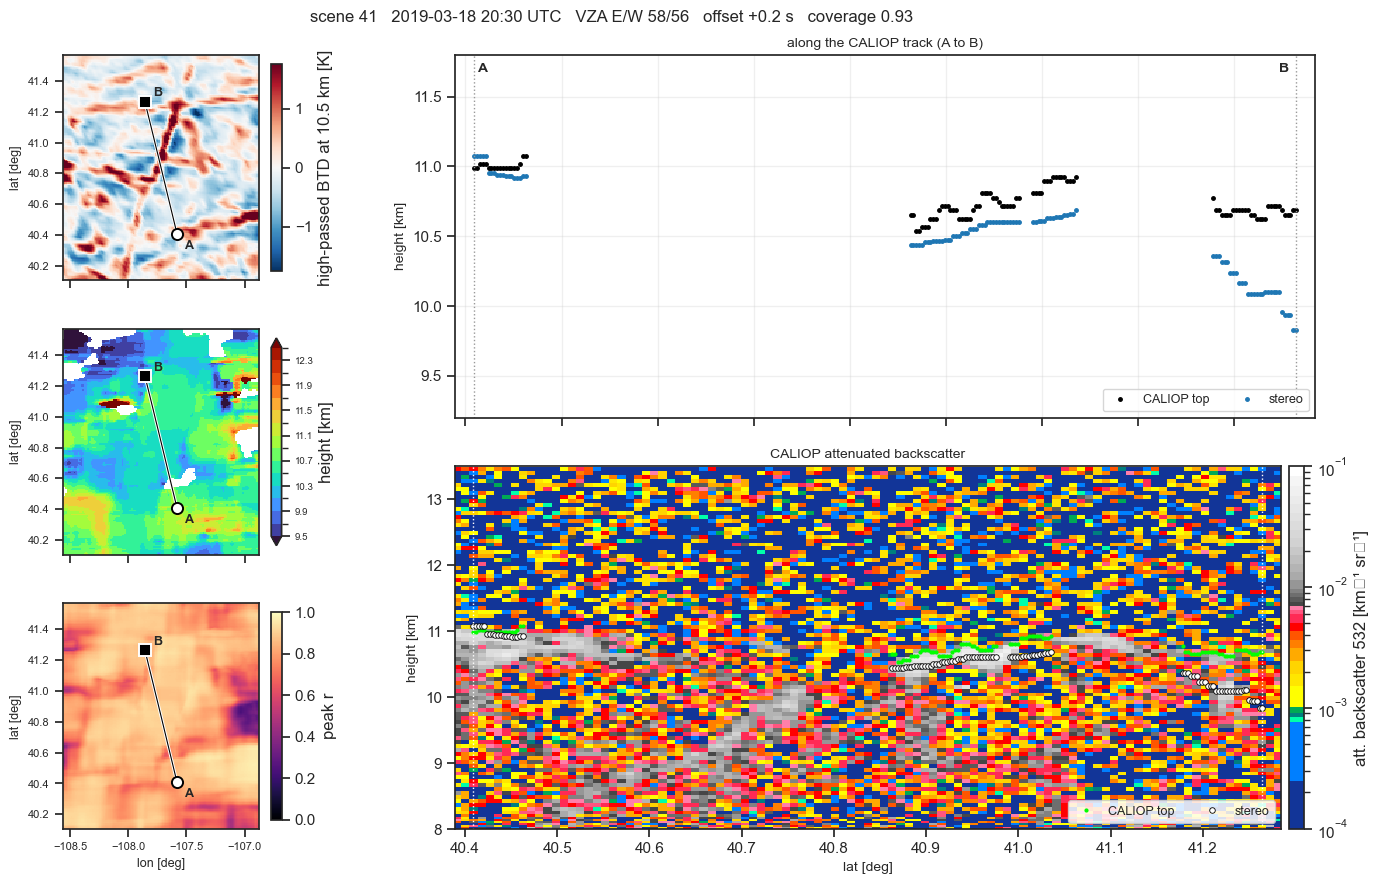

In [ ]:
# ---- Case summary figure, slide layout: maps in a left column, wide panels right ----
# Needs: res, truth, frames, case, CFG, vis (+ optional `s` = L1 dict for the curtain).
from matplotlib.colors import LogNorm
H_LIMS = (9.5, 12.5)          # height colour range [km]
H_STEP = 0.2
Z_LIMS = (8.0, 13.5)          # curtain altitude range [km]
BETA = (1e-4, 1e-1)           # attenuated backscatter [km-1 sr-1]
FIGSIZE = (16, 9)             # 16:9 for a full-slide figure
try:
    import warnings; warnings.filterwarnings("ignore", message=".*earthcarekit.*")
    import earthcarekit as eck
    BETA_CMAP = eck.get_cmap("calipso")
except Exception:                                                     # noqa: BLE001
    BETA_CMAP = "turbo"

g = res.grid
t = truth.sort_values("pid")
A_pt, B_pt = t.iloc[0], t.iloc[-1]
has_l1 = "s" in globals() and isinstance(globals().get("s"), dict) and "beta" in globals()["s"]

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(6, 2, width_ratios=[1.0, 2.15], hspace=0.55, wspace=0.26,
                      left=0.05, right=0.94, top=0.93, bottom=0.07)

cm, norm, edges, ticks, labels = vis.height_norm(H_LIMS, H_STEP)
from contrailstereo.prep import highpass
from contrailstereo.geometry import km_filters, apparent_surface_latlon
H_REF = res.diag.get("s_eff_h_ref", 11.0)          # the case's median retrieved height
fE_ = frames[(CFG.sat_east, 0)]
al, ao = apparent_surface_latlon(g.lat, g.lon, H_REF * 1e3, fE_.sat_lon)
BTD = highpass(fE_.view(al, ao), km_filters(g, CFG)[0])
vb = np.nanpercentile(np.abs(BTD), 99)
panels = [(f"high-passed BTD at {H_REF:.1f} km [K]", BTD, dict(cmap="RdBu_r", vmin=-vb, vmax=vb), None),
          ("height [km]", res.height, dict(cmap=cm, norm=norm), (ticks, labels)),
          ("peak r", res.r, dict(cmap="magma", vmin=0, vmax=1), None)]
for k, (lab, Z, kw, cbticks) in enumerate(panels):
    ax = fig.add_subplot(gs[2 * k:2 * k + 2, 0])
    pm = ax.pcolormesh(g.lon, g.lat, Z, shading="auto", **kw)
    cb = fig.colorbar(pm, ax=ax, shrink=0.92, pad=0.03, fraction=0.05, label=lab)
    if cbticks:
        cb.set_ticks(cbticks[0]); cb.set_ticklabels(cbticks[1])
        cb.ax.tick_params(labelsize=7)
    ax.plot(t.lon, t.lat, "-", color="w", lw=2.2)
    ax.plot(t.lon, t.lat, "-", color="k", lw=0.8)
    ax.plot(A_pt.lon, A_pt.lat, "o", ms=8, mfc="w", mec="k", mew=1.4, zorder=5)
    ax.plot(B_pt.lon, B_pt.lat, "s", ms=8, mfc="k", mec="w", mew=1.4, zorder=5)
    ax.annotate("A", (A_pt.lon, A_pt.lat), xytext=(6, -11), textcoords="offset points",
                fontsize=9, fontweight="bold")
    ax.annotate("B", (B_pt.lon, B_pt.lat), xytext=(6, 4), textcoords="offset points",
                fontsize=9, fontweight="bold")
    ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0])))
    ax.tick_params(labelsize=8)
    ax.set_ylabel("lat [deg]", fontsize=9)
    if k == 2:
        ax.set_xlabel("lon [deg]", fontsize=9)
    else:
        ax.tick_params(labelbottom=False)

rows_top = slice(0, 3) if has_l1 else slice(0, 6)
ax = fig.add_subplot(gs[rows_top, 1])
ax.plot(t.lat, t.top_km, ".", ms=5, color="k", label="CALIOP top")
ax.plot(t.lat, t.h, ".", ms=5, color="C0", label="stereo")
zz = np.r_[t.top_km.dropna().values, t.h.dropna().values]
ax.set_ylim(np.floor(zz.min() * 2) / 2 - 0.3, np.ceil(zz.max() * 2) / 2 + 0.3)
ax.set_ylabel("height [km]", fontsize=10); ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="lower right", ncol=2)
ax.set_title("along the CALIOP track (A to B)", fontsize=10)
for x_ in (A_pt.lat, B_pt.lat):
    ax.axvline(x_, color="0.6", lw=1, ls=":")
ax.annotate("A", (A_pt.lat, ax.get_ylim()[1]), xytext=(3, -12), textcoords="offset points",
            fontsize=10, fontweight="bold")
ax.annotate("B", (B_pt.lat, ax.get_ylim()[1]), xytext=(-12, -12), textcoords="offset points",
            fontsize=10, fontweight="bold")

if has_l1:
    ax2 = fig.add_subplot(gs[3:6, 1], sharex=ax)
    kz = (s["alt"] >= Z_LIMS[0]) & (s["alt"] <= Z_LIMS[1])
    pm = ax2.pcolormesh(s["lat"], s["alt"][kz], np.clip(s["beta"][:, kz], BETA[0], None).T,
                        norm=LogNorm(*BETA), cmap=BETA_CMAP, shading="nearest", rasterized=True)
    fig.colorbar(pm, ax=ax2, pad=0.01, fraction=0.03, aspect=25,
                 label="att. backscatter 532 [km⁻¹ sr⁻¹]")
    ax2.plot(t.lat, t.top_km, ".", ms=4, color="lime", label="CALIOP top")
    ax2.plot(t.lat, t.h, "o", ms=4, mfc="w", mec="k", mew=0.6, label="stereo")
    ax2.set_ylim(*Z_LIMS); ax2.set_xlabel("lat [deg]", fontsize=10)
    ax2.set_ylabel("height [km]", fontsize=10)
    ax2.legend(fontsize=9, loc="lower right", facecolor="white", framealpha=0.85, ncol=2)
    ax2.set_title("CALIOP attenuated backscatter", fontsize=10)
    for x_ in (A_pt.lat, B_pt.lat):
        ax2.axvline(x_, color="w", lw=1, ls=":")
    ax.set_xlim(min(A_pt.lat, B_pt.lat) - 0.02, max(A_pt.lat, B_pt.lat) + 0.02)
    ax.tick_params(labelbottom=False)
else:
    ax.set_xlabel("lat [deg]", fontsize=10)

d_ = res.diag
fig.suptitle(f"scene {case.meta['scene']}   {case.time:%Y-%m-%d %H:%M} UTC   "
             f"VZA E/W {d_['vza_east']:.0f}/{d_['vza_west']:.0f}   "
             f"offset {d_['offset_s']:+.1f} s   coverage {d_['map_coverage']:.2f}", fontsize=12)

/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/lewisclark/miniforge3/envs/contrails_lewis/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


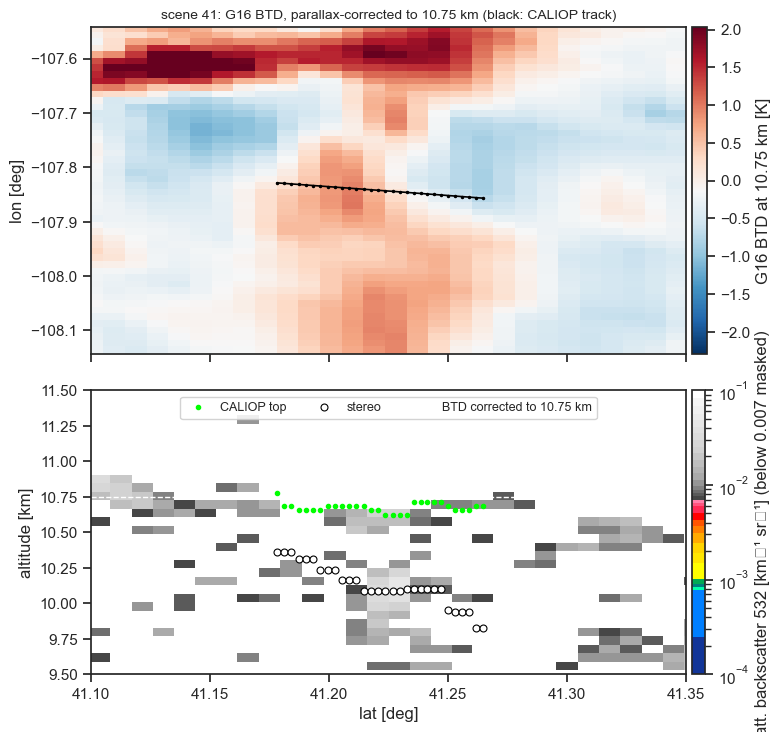

In [ ]:
# ---- Zoom on one contrail: BTD (corrected to H_CORR) above the CALIOP curtain -------
BETA_MIN_SHOW = 7e-3          # hide anything weaker than this

# Needs: res, truth, frames, case, CFG (+ `s` = L1 dict: lat/alt/beta).
from matplotlib.colors import LogNorm
from contrailstereo.geometry import apparent_surface_latlon
LAT_LIMS = (41.1, 41.35)     # the stretch of track to examine
LON_PAD = 0.30                # degrees of longitude either side of the track
H_CORR = 10.75                 # height the BTD is parallax-corrected to [km]
Z_LIMS = (9.5, 11.5)          # curtain altitude range [km]
BETA = (1e-4, 1e-1)
SAT = CFG.sat_east            # which view to show
try:
    import warnings; warnings.filterwarnings("ignore", message=".*earthcarekit.*")
    import earthcarekit as eck
    BETA_CMAP = eck.get_cmap("calipso")
except Exception:                                                     # noqa: BLE001
    BETA_CMAP = "turbo"

g = res.grid
t = truth[(truth.lat >= LAT_LIMS[0]) & (truth.lat <= LAT_LIMS[1])].sort_values("lat")
lon_c = t.lon.median()
f = frames[(SAT, 0)]
al, ao = apparent_surface_latlon(g.lat, g.lon, H_CORR * 1e3, f.sat_lon)
BTD = highpass(f.view(al, ao), km_filters(g, CFG)[0])                      # each pixel shows what the view puts at H_CORR

fig, axs = plt.subplots(2, 1, figsize=(8, 8.4), sharex=True,
                        gridspec_kw=dict(height_ratios=[1.15, 1.0], hspace=0.12))
ax = axs[0]
sel = ((g.lat >= LAT_LIMS[0] - 0.02) & (g.lat <= LAT_LIMS[1] + 0.02)
       & (np.abs(g.lon - lon_c) <= LON_PAD))
med = np.nanmedian(BTD[sel]); v = np.nanpercentile(np.abs(BTD[sel] - med), 99)
pm = ax.pcolormesh(g.lat.T, g.lon.T, BTD.T, cmap="RdBu_r", vmin=med - v, vmax=med + v,
                   shading="auto")                       # transposed: latitude on x
fig.colorbar(pm, ax=ax, pad=0.01, fraction=0.03, aspect=22,
             label=f"G{SAT} BTD at {H_CORR} km [K]")
ax.plot(t.lat, t.lon, "-", color="k", lw=1.2)
ax.plot(t.lat, t.lon, ".", color="k", ms=3)
ax.set_ylim(lon_c - LON_PAD, lon_c + LON_PAD)
ax.set_ylabel("lon [deg]")
ax.set_title(f"scene {case.meta['scene']}: G{SAT} BTD, parallax-corrected to {H_CORR} km "
             f"(black: CALIOP track)", fontsize=10)

ax = axs[1]
kz = (s["alt"] >= Z_LIMS[0]) & (s["alt"] <= Z_LIMS[1])
kl = (s["lat"] >= LAT_LIMS[0] - 0.02) & (s["lat"] <= LAT_LIMS[1] + 0.02)
Bz = np.ma.masked_less(s["beta"][kl][:, kz], BETA_MIN_SHOW)
cmap_b = (BETA_CMAP.copy() if hasattr(BETA_CMAP, "copy") else plt.get_cmap(BETA_CMAP).copy())
cmap_b.set_bad("white")                     # masked (weak) pixels
pm = ax.pcolormesh(s["lat"][kl], s["alt"][kz], Bz.T,
                   norm=LogNorm(*BETA), cmap=cmap_b, shading="nearest", rasterized=True)
fig.colorbar(pm, ax=ax, pad=0.01, fraction=0.03, aspect=22,
             label=f"att. backscatter 532 [km⁻¹ sr⁻¹] (below {BETA_MIN_SHOW:g} masked)")
ax.plot(t.lat, t.top_km, ".", ms=6, color="lime", label="CALIOP top")
ax.plot(t.lat, t.h, "o", ms=5, mfc="w", mec="k", mew=0.8, label="stereo")
ax.axhline(H_CORR, color="w", lw=1, ls="--", label=f"BTD corrected to {H_CORR} km")
ax.set_ylim(*Z_LIMS); ax.set_xlim(*LAT_LIMS)
ax.set_xlabel("lat [deg]"); ax.set_ylabel("altitude [km]")
ax.legend(fontsize=9, loc="upper center", facecolor="white", framealpha=0.85, ncol=3)

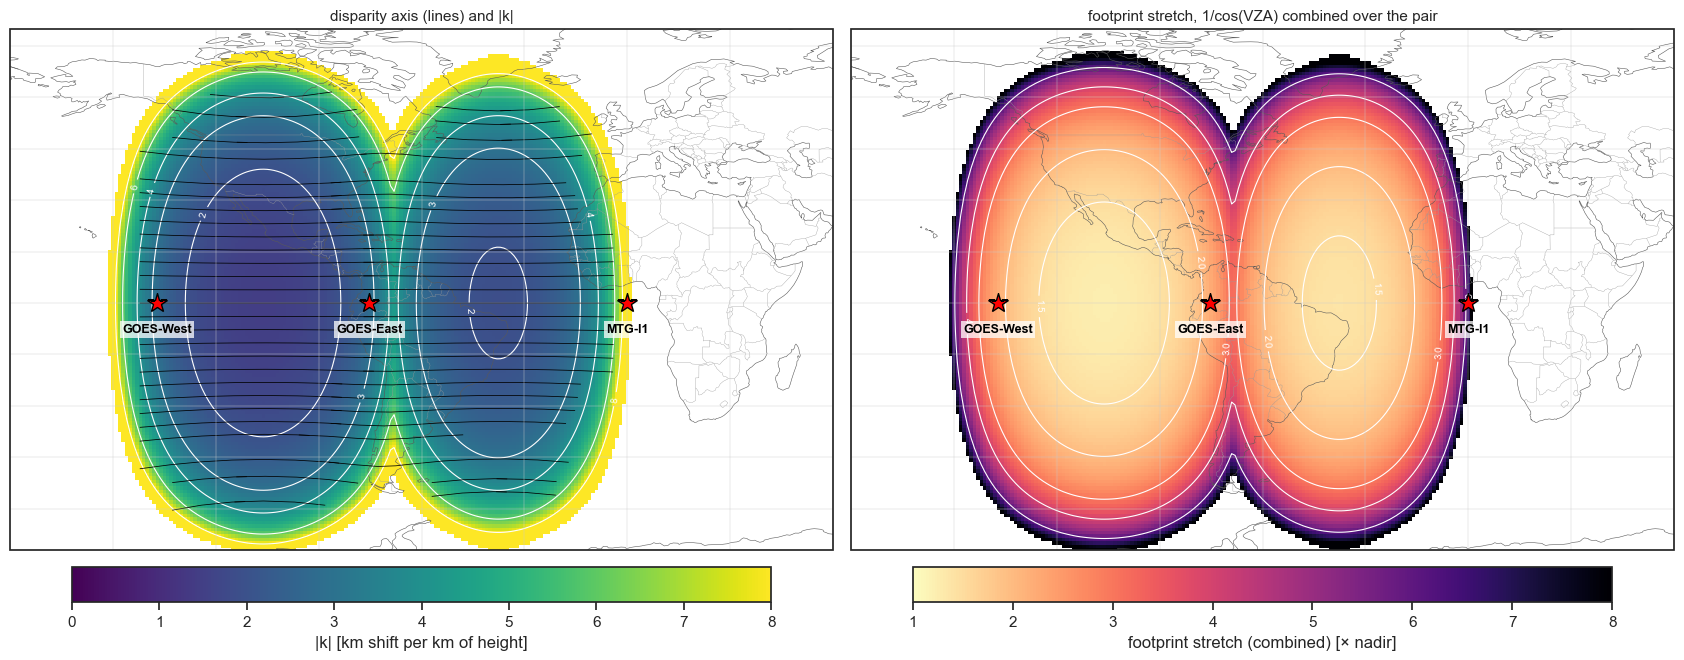

In [ ]:
# ---- Both GEO pairs, filled on one map: disparity axis, |k|, footprint stretch ------
# Where the two domains overlap, the pair with the better (smaller) worst-case VZA is shown.
from contrailstereo.geometry import disparity_per_km, vza_deg
import contrailstereo.config as _cfg, contrailstereo.geometry as _geo
PAIRS = [("GOES-West / GOES-East", (-137.2, -75.2), "k"),
         ("GOES-East / MTG-I1",    (-75.2, 0.0),    "w")]
MAX_VZA = 85.0
STEP = 1.0
LON_LIMS, LAT_LIMS = (-180, 60), (-72, 80)

lats = np.arange(LAT_LIMS[0], LAT_LIMS[1] + 1e-9, STEP)
lons = np.arange(LON_LIMS[0], LON_LIMS[1] + 1e-9, STEP)
LA, LO = np.meshgrid(lats, lons, indexing="ij")
_IDS = (901, 902)
K = np.full(LA.shape, np.nan); KN = K.copy(); KE = K.copy()
STR = K.copy(); BEST = np.full(LA.shape, np.nan); VBEST = np.full(LA.shape, np.inf)
EDGE = {}
for p_, (name, lon_pair, col) in enumerate(PAIRS):
    for _m in (_cfg, _geo):
        if hasattr(_m, "SAT_LON"):
            _m.SAT_LON = {**_m.SAT_LON, _IDS[0]: lon_pair[0], _IDS[1]: lon_pair[1]}
    va = np.array([[vza_deg(a, o, lon_pair[0]) for o in lons] for a in lats])
    vb = np.array([[vza_deg(a, o, lon_pair[1]) for o in lons] for a in lats])
    vmax = np.fmax(va, vb)
    EDGE[name] = vmax
    take = (vmax <= MAX_VZA) & (vmax < VBEST)          # this pair has the better geometry here
    idx = np.argwhere(take)
    for i, j in idx:
        KN[i, j], KE[i, j] = disparity_per_km(LA[i, j], LO[i, j], *_IDS)
    K[take] = np.hypot(KN[take], KE[take])
    STR[take] = (np.hypot(1 / np.cos(np.deg2rad(va)), 1 / np.cos(np.deg2rad(vb))) / np.sqrt(2))[take]
    VBEST[take] = vmax[take]; BEST[take] = p_

try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    proj, tr = ccrs.PlateCarree(), dict(transform=ccrs.PlateCarree())
except Exception:                                                     # noqa: BLE001
    proj, tr = None, {}

fig = plt.figure(figsize=(17, 9))
axs = [fig.add_subplot(1, 2, i + 1, projection=proj) if proj else fig.add_subplot(1, 2, i + 1)
       for i in range(2)]

ax = axs[0]
pm = ax.pcolormesh(lons, lats, K, cmap="viridis", shading="auto", vmin=0, vmax=8, **tr)
fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02, label="|k| [km shift per km of height]", orientation="horizontal")
cs = ax.contour(lons, lats, K, levels=[2, 3, 4, 6, 8], colors="w", linewidths=0.8, **tr)
ax.clabel(cs, fmt="%.0f", fontsize=7)
ang = (np.degrees(np.arctan2(KE, KN)) + 180) % 180
u, v_ = np.sin(np.deg2rad(ang)), np.cos(np.deg2rad(ang))
ax.streamplot(lons, lats, u, v_, color="k", density=1.3, linewidth=0.55, arrowstyle="-", **tr)
ax.set_title("disparity axis (lines) and |k|", fontsize=11)

ax = axs[1]
pm = ax.pcolormesh(lons, lats, STR, cmap="magma_r", shading="auto", vmin=1, vmax=8, **tr)
fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02, label="footprint stretch (combined) [× nadir]", orientation="horizontal")
cs = ax.contour(lons, lats, STR, levels=[1.5, 2, 3, 4, 6], colors="w", linewidths=0.8, **tr)
ax.clabel(cs, fmt="%.1f", fontsize=7)
ax.set_title("footprint stretch, 1/cos(VZA) combined over the pair", fontsize=11)

for ax in axs:
    if proj:
        try:
            ax.add_feature(cfeature.COASTLINE, lw=0.4, edgecolor="0.35")
            ax.add_feature(cfeature.BORDERS, lw=0.25, edgecolor="0.6")
        except Exception as e:                                        # noqa: BLE001
            print(f"(coastlines unavailable: {type(e).__name__})")
        ax.gridlines(draw_labels=False, lw=0.3, color="0.8", xlocs=range(-180, 61, 30),
                     ylocs=range(-60, 81, 15))
        ax.set_extent([*LON_LIMS, *LAT_LIMS], crs=proj)
    else:
        ax.set_xlim(*LON_LIMS); ax.set_ylim(*LAT_LIMS); ax.grid(alpha=0.25)
    SATS = [("GOES-West", -137.2), ("GOES-East", -75.2), ("MTG-I1", 0.0)]
    for name_, lon0 in SATS:
        ax.plot(lon0, 0, "*", color="r", ms=15, mec="k", zorder=6, **tr)
        ax.text(lon0, -6, name_, color="k", fontsize=9, fontweight="bold", ha="center",
                va="top", zorder=6,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.5), **tr)
    #ax.plot([-65, -10, -10, -65, -65], [45, 45, 62, 62, 45], "-", color="cyan", lw=1.6, **tr)
fig.tight_layout()